In [21]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [22]:
PROCESSED_DATA_DIR = Path("../data/processed")

In [23]:
training_actions_df = pd.read_csv(PROCESSED_DATA_DIR / "training_actions.csv", sep=",", encoding="utf-8", parse_dates=["start_date", "end_date"])


info_actions_df = pd.read_csv(PROCESSED_DATA_DIR / "info_actions.csv", sep=",", encoding="utf-8")

In [24]:
actions_analysis_df = training_actions_df.merge(
    info_actions_df, how="inner", on="course_id", validate="many_to_one"
)

actions_analysis_df = actions_analysis_df.loc[actions_analysis_df["active"]].drop_duplicates(subset=["action_id", "local", "status"])

actions_analysis_df

,action_id,course_id,local,start_date,end_date,modality,status,total_students,course_name,course_area,total_hours,active
0,P_HCP_0001,HCP,Centro 1,2018-01-01,2018-01-02,In-person,Finalizada,11,HACCP Aplicado,Alimentar,12,True
1,P_INF_0001,INF,Centro 1,2018-01-01,2018-01-03,In-person,Finalizada,11,"Infeção, Prevenção e Controlo",Saúde,16,True
2,P_PRI_0001,PRI,Centro 1,2018-01-01,2018-01-03,In-person,Finalizada,15,Primeiros Socorros,Saúde e Segurança,12,True
3,H_TUR_0004,TUR,Centro 5,2018-01-01,2018-01-05,Hybrid,Finalizada,20,Atendimento Turístico,Turismo,16,True
4,H_INF_0005,INF,Centro 5,2018-01-01,2018-01-06,Hybrid,Finalizada,20,"Infeção, Prevenção e Controlo",Saúde,16,True
...,...,...,...,...,...,...,...,...,...,...,...,...
19120,P_HAC_0778,HAC,Centro 4,2026-12-30,2026-12-31,In-person,Prevista,25,Higiene e Segurança Alimentar,Alimentar,8,True
19121,H_ING_0583,ING,Centro 2,2026-12-30,2026-12-31,Hybrid,Prevista,21,Inglês Profissional,Línguas,30,True
19122,E_PRO_0618,PRO,Centro 4,2026-12-30,2026-12-31,Online,Prevista,31,Gestão de Projetos,Gestão,25,True
19123,P_SCI_0684,SCI,Centro 3,2026-12-30,2026-12-31,In-person,Prevista,21,Segurança Contra Incêndios,Segurança,8,True


In [25]:
total_actions = actions_analysis_df["action_id"].nunique()
total_status = actions_analysis_df["status"].nunique()
total_modalities = actions_analysis_df["modality"].nunique()
total_time = (
    actions_analysis_df["end_date"].max() - actions_analysis_df["start_date"].min()
).days / 365

print(
    f"""
Total Actions: {total_actions}
Number of Status: {total_status}
Number of Modalities: {total_modalities}
Period of Time: {total_time:.0f} years
""".strip()
)

Total Actions: 19125
Number of Status: 4
Number of Modalities: 3
Period of Time: 9 years


In [26]:
def summarize_actions(df, group_columns):
    summary = (
        df
        .groupby(group_columns, as_index=False)
        .agg(
            actions_count=("action_id", "nunique"),
            students_count=("total_students", "sum")
        )
        .assign(
            pct_actions=lambda data:
                data["actions_count"]
                .div(data["actions_count"].sum())
                .mul(100)
                .round(1),

            pct_students=lambda data:
                data["students_count"]
                .div(data["students_count"].sum())
                .mul(100)
                .round(1)
        )
        .sort_values(
            by="actions_count",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return summary

In [27]:
actions_course_count = summarize_actions(
    actions_analysis_df,
    ["course_id", "course_name"]
)

actions_course_count

,course_id,course_name,actions_count,students_count,pct_actions,pct_students
0,CYB,Cibersegurança Básica,1214,25214,6.3,7.0
1,PBI,Power BI e Visualização de Dados,1209,25308,6.3,7.0
2,SEG,Segurança no Trabalho,1069,20473,5.6,5.7
3,EXC,Excel Aplicado à Gestão,1024,21029,5.4,5.8
4,SST,Saúde e Segurança no Trabalho,1012,19273,5.3,5.3
5,PRI,Primeiros Socorros,953,16724,5.0,4.6
6,GER,Geriatria e Apoio ao Idoso,937,16200,4.9,4.5
7,LOG,Logística e Gestão de Armazém,909,16084,4.8,4.4
8,MNT,Manutenção Industrial Básica,851,14091,4.4,3.9
9,PYT,Introdução à Programação em Python,789,16572,4.1,4.6


In [28]:
actions_local_count = summarize_actions(
    actions_analysis_df,
    ["local"]
)

actions_local_count

,local,actions_count,students_count,pct_actions,pct_students
0,Centro 2,4090,78532,21.4,21.7
1,Centro 4,3845,73373,20.1,20.3
2,Centro 1,3818,71843,20.0,19.8
3,Centro 5,3741,69936,19.6,19.3
4,Centro 3,3631,68253,19.0,18.9


In [29]:
actions_status_count = summarize_actions(
    actions_analysis_df,
    ["status"]
)

actions_status_count

,status,actions_count,students_count,pct_actions,pct_students
0,Finalizada,16619,323260,86.9,89.3
1,Prevista,1582,34344,8.3,9.5
2,Cancelada,866,3035,4.5,0.8
3,Em andamento,58,1298,0.3,0.4


In [30]:
actions_modalities_count = summarize_actions(
    actions_analysis_df,
    ["modality"]
)

actions_modalities_count

,modality,actions_count,students_count,pct_actions,pct_students
0,In-person,9357,154288,48.9,42.6
1,Hybrid,6188,120835,32.4,33.4
2,Online,3580,86814,18.7,24.0


In [31]:
actions_area_count = summarize_actions(
    actions_analysis_df,
    ["course_area"]
)

actions_area_count

,course_area,actions_count,students_count,pct_actions,pct_students
0,Informática,4236,88123,22.1,24.3
1,Segurança,3372,62005,17.6,17.1
2,Gestão,1999,39791,10.5,11.0
3,Saúde,1627,28153,8.5,7.8
4,Alimentar,1480,26839,7.7,7.4
5,Saúde e Segurança,1433,25091,7.5,6.9
6,Turismo,1195,20827,6.2,5.8
7,Logística,909,16084,4.8,4.4
8,Manutenção,851,14091,4.4,3.9
9,Comercial,754,14901,3.9,4.1


In [32]:
actions_course_local_count = summarize_actions(
    actions_analysis_df,
    ["course_id", "course_name", "local"]
)

actions_course_local_count

,course_id,course_name,local,actions_count,students_count,pct_actions,pct_students
0,PBI,Power BI e Visualização de Dados,Centro 4,324,6768,1.7,1.9
1,CYB,Cibersegurança Básica,Centro 4,320,6615,1.7,1.8
2,PBI,Power BI e Visualização de Dados,Centro 2,319,6718,1.7,1.9
3,CYB,Cibersegurança Básica,Centro 2,307,6190,1.6,1.7
4,SEG,Segurança no Trabalho,Centro 5,268,5103,1.4,1.4
...,...,...,...,...,...,...,...
115,HOT,Housekeeping e Operações Hoteleiras,Centro 4,85,1440,0.4,0.4
116,SOC,Socorrismo Básico,Centro 2,84,1470,0.4,0.4
117,TUR,Atendimento Turístico,Centro 3,83,1354,0.4,0.4
118,SOC,Socorrismo Básico,Centro 1,67,1215,0.4,0.3


In [33]:
actions_course_modality_count = summarize_actions(
    actions_analysis_df,
    ["course_id", "course_name", "modality"]
)

actions_course_modality_count

,course_id,course_name,modality,actions_count,students_count,pct_actions,pct_students
0,MNT,Manutenção Industrial Básica,In-person,851,14091,4.4,3.9
1,PRI,Primeiros Socorros,In-person,640,10623,3.3,2.9
2,GER,Geriatria e Apoio ao Idoso,In-person,615,10135,3.2,2.8
3,EMP,Empilhadores e Movimentação de Cargas,In-person,606,10046,3.2,2.8
4,LOG,Logística e Gestão de Armazém,In-person,590,9821,3.1,2.7
5,SEG,Segurança no Trabalho,In-person,541,9068,2.8,2.5
6,PBI,Power BI e Visualização de Dados,Online,517,12423,2.7,3.4
7,SST,Saúde e Segurança no Trabalho,In-person,507,8405,2.7,2.3
8,CYB,Cibersegurança Básica,Online,486,11692,2.5,3.2
9,HCP,HACCP Aplicado,In-person,474,7701,2.5,2.1


In [34]:
actions_course_status_count = summarize_actions(
    actions_analysis_df,
    ["course_id", "course_name", "status"]
)

actions_course_status_count

,course_id,course_name,status,actions_count,students_count,pct_actions,pct_students
0,CYB,Cibersegurança Básica,Finalizada,1031,22056,5.4,6.1
1,PBI,Power BI e Visualização de Dados,Finalizada,1023,22061,5.3,6.1
2,SEG,Segurança no Trabalho,Finalizada,955,18705,5.0,5.2
3,SST,Saúde e Segurança no Trabalho,Finalizada,890,17333,4.7,4.8
4,EXC,Excel Aplicado à Gestão,Finalizada,874,18813,4.6,5.2
...,...,...,...,...,...,...,...
84,EXC,Excel Aplicado à Gestão,Em andamento,1,26,0.0,0.0
85,TUR,Atendimento Turístico,Em andamento,1,29,0.0,0.0
86,EMP,Empilhadores e Movimentação de Cargas,Em andamento,1,16,0.0,0.0
87,PRI,Primeiros Socorros,Em andamento,1,22,0.0,0.0


In [35]:
actions_local_modalities_count = summarize_actions(
    actions_analysis_df,
    ["local", "modality"]
)

actions_local_modalities_count

,local,modality,actions_count,students_count,pct_actions,pct_students
0,Centro 5,In-person,1947,32229,10.2,8.9
1,Centro 1,In-person,1901,31051,9.9,8.6
2,Centro 3,In-person,1869,30910,9.8,8.5
3,Centro 2,In-person,1864,30932,9.7,8.5
4,Centro 4,In-person,1776,29166,9.3,8.1
5,Centro 2,Hybrid,1357,26411,7.1,7.3
6,Centro 1,Hybrid,1244,24464,6.5,6.8
7,Centro 4,Hybrid,1241,24277,6.5,6.7
8,Centro 5,Hybrid,1174,22733,6.1,6.3
9,Centro 3,Hybrid,1172,22950,6.1,6.3


In [36]:
actions_local_status_count = summarize_actions(
    actions_analysis_df,
    ["local", "status"]
)

actions_local_status_count

,local,status,actions_count,students_count,pct_actions,pct_students
0,Centro 2,Finalizada,3536,69961,18.5,19.3
1,Centro 4,Finalizada,3345,65690,17.5,18.1
2,Centro 1,Finalizada,3336,64402,17.4,17.8
3,Centro 5,Finalizada,3245,62297,17.0,17.2
4,Centro 3,Finalizada,3157,60910,16.5,16.8
5,Centro 2,Prevista,358,7683,1.9,2.1
6,Centro 5,Prevista,313,6747,1.6,1.9
7,Centro 1,Prevista,306,6733,1.6,1.9
8,Centro 4,Prevista,305,6650,1.6,1.8
9,Centro 3,Prevista,300,6531,1.6,1.8


In [37]:
actions_modality_status_count = summarize_actions(
    actions_analysis_df,
    ["modality", "status"]
)

actions_modality_status_count

,modality,status,actions_count,students_count,pct_actions,pct_students
0,In-person,Finalizada,8150,138171,42.6,38.2
1,Hybrid,Finalizada,5384,107813,28.2,29.8
2,Online,Finalizada,3085,77276,16.1,21.4
3,In-person,Prevista,751,14365,3.9,4.0
4,Hybrid,Prevista,523,11633,2.7,3.2
5,In-person,Cancelada,445,1559,2.3,0.4
6,Online,Prevista,308,8346,1.6,2.3
7,Hybrid,Cancelada,259,921,1.4,0.3
8,Online,Cancelada,162,555,0.8,0.2
9,Online,Em andamento,25,637,0.1,0.2


In [38]:
all_actions_count = summarize_actions(
    actions_analysis_df,
    ["course_id", "course_name", "local", "modality", "status"]
)

all_actions_count

,course_id,course_name,local,modality,status,actions_count,students_count,pct_actions,pct_students
0,MNT,Manutenção Industrial Básica,Centro 1,In-person,Finalizada,192,3155,1.0,0.9
1,MNT,Manutenção Industrial Básica,Centro 5,In-person,Finalizada,171,2921,0.9,0.8
2,GER,Geriatria e Apoio ao Idoso,Centro 3,In-person,Finalizada,157,2710,0.8,0.7
3,PRI,Primeiros Socorros,Centro 3,In-person,Finalizada,155,2685,0.8,0.7
4,MNT,Manutenção Industrial Básica,Centro 4,In-person,Finalizada,149,2558,0.8,0.7
...,...,...,...,...,...,...,...,...,...
879,GER,Geriatria e Apoio ao Idoso,Centro 4,Hybrid,Em andamento,1,24,0.0,0.0
880,SST,Saúde e Segurança no Trabalho,Centro 1,Online,Cancelada,1,7,0.0,0.0
881,PYT,Introdução à Programação em Python,Centro 5,In-person,Em andamento,1,15,0.0,0.0
882,PYT,Introdução à Programação em Python,Centro 5,Online,Cancelada,1,5,0.0,0.0


In [ ]:
def plot_actions_overview(charts, title, ylabel="Number of Actions", nrows=2, ncols=2, figsize=(13, 9)):

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, facecolor="#E9ECEF")

    fig.suptitle(title, fontsize=16, fontweight="bold")

    for ax, chart in zip(axes.flat, charts.values()):

        plot_df = chart["df"].copy()

        if "top_n" in chart:
            plot_df = plot_df.head(chart["top_n"])

        categories = plot_df[chart["label_column"]].astype(str)
        values = plot_df["actions_count"]
        percentages = plot_df["pct_actions"]

        bars = ax.bar(categories, values)

        labels = [
            f"{value}\n({percentage:.1f}%)"
            for value, percentage in zip(values, percentages)
        ]

        ax.bar_label(bars, labels=labels, padding=4, fontsize=8)

        ax.set_title(chart["title"], loc="left", fontweight="bold", pad=25)

        ax.text(
            0,
            1.02,
            chart["description"],
            transform=ax.transAxes,
            fontsize=9,
            color="#6B7280"
        )

        ax.set_facecolor("#FFFFFF")
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, values.max() * 1.25)

        ax.tick_params(axis="x", rotation=45)

        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

    plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3)

    plt.show()

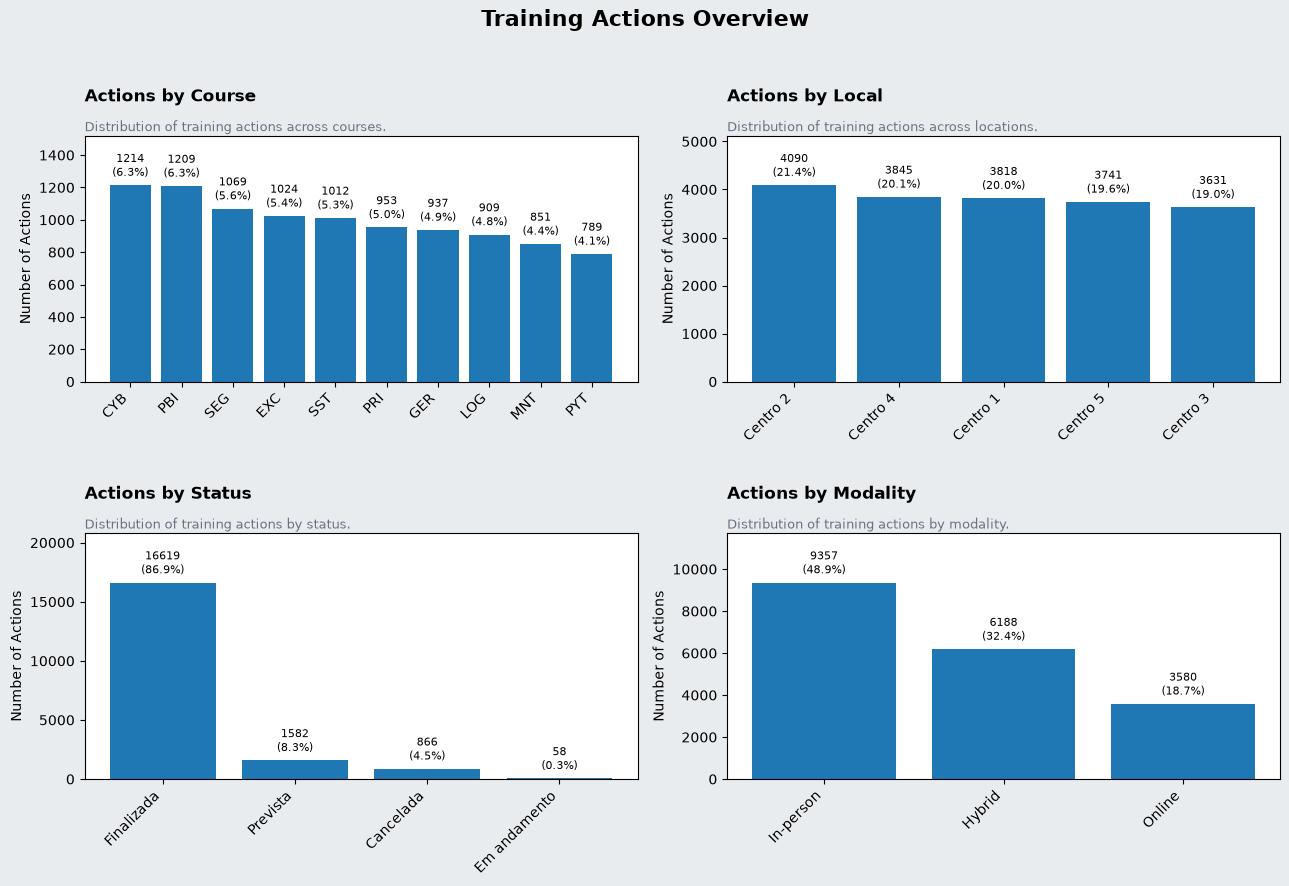

In [40]:
actions_overview_charts = {
    "courses": {
        "df": actions_course_count,
        "label_column": "course_id",
        "title": "Actions by Course",
        "description": "Distribution of training actions across courses.",
        "top_n": 10
    },

    "locals": {
        "df": actions_local_count,
        "label_column": "local",
        "title": "Actions by Local",
        "description": "Distribution of training actions across locations."
    },

    "status": {
        "df": actions_status_count,
        "label_column": "status",
        "title": "Actions by Status",
        "description": "Distribution of training actions by status."
    },

    "modalities": {
        "df": actions_modalities_count,
        "label_column": "modality",
        "title": "Actions by Modality",
        "description": "Distribution of training actions by modality."
    }
}

plot_actions_overview(
    charts=actions_overview_charts,
    title="Training Actions Overview"
)